# 00 · Python for rheology data

**Goal:** the Python tools used throughout the course - reading rheometer exports, units, log-scale
plots, local slopes and a first model fit - on one realistic data set.

**The data.** A flow curve of a 0.5 % xanthan gum solution (a thickener used in food, cosmetics and
drilling fluids) measured with a cone-plate rheometer. The file is a plain CSV export with a short
description at the top - the format every rheometer can produce.

**What you will learn**
- read a rheometer CSV export with pandas and check its units
- plot flow curves on log scales
- compute local slopes and a power-law fit
- interpolate on the right scale

**Before you start:** basic Python (variables, lists, functions); no rheology needed  ·  **Time:** about 45 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import datasets, fitting, geometry
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Look at the file, then read it

In [2]:
path = datasets.path("xanthan_flow_curve.csv")
with open(path, encoding="utf-8") as fh:
    print("".join(fh.readlines()[:6]))
df = pd.read_csv(path, comment="#")
print(df.shape); print(df.head(3))

# 0.5 wt% xanthan gum in water, 25 degC. Cone-plate: R = 25 mm, cone angle 1.0 deg. Steady-state flow curve.
# Columns: shear rate (1/s), shear stress (Pa), viscosity (Pa s), torque (N m).
shear_rate_1_s,shear_stress_Pa,viscosity_Pa_s,torque_Nm
0.01,0.34265,34.265,1.1213e-05
0.014678,0.51033,34.768,1.67e-05
0.021544,0.70859,32.89,2.3188e-05

(31, 4)
   shear_rate_1_s  shear_stress_Pa  viscosity_Pa_s  torque_Nm
0        0.010000          0.34265          34.265   0.000011
1        0.014678          0.51033          34.768   0.000017
2        0.021544          0.70859          32.890   0.000023


The comment lines hold what the numbers mean: geometry, temperature, units. Always read them - a flow
curve without its temperature and geometry is only half a result.

## Check the units and the internal consistency
Viscosity should equal stress divided by shear rate, and the stress should follow from the torque with the
cone-plate formula $\tau = 3M/(2\pi R^3)$:

In [3]:
rate, tau, eta, M = df.shear_rate_1_s.to_numpy(), df.shear_stress_Pa.to_numpy(), df.viscosity_Pa_s.to_numpy(), df.torque_Nm.to_numpy()
print("max |eta - tau/rate| / eta:", np.max(np.abs(eta - tau / rate) / eta))
tau_from_torque, rate_check = geometry.cone_plate(M, rate * np.radians(1.0), R=0.025, theta=np.radians(1.0))
print("max |tau from torque - tau| / tau:", np.max(np.abs(tau_from_torque - tau) / tau))

max |eta - tau/rate| / eta: 3.6095176159659104e-05
max |tau from torque - tau| / tau: 3.8414143749421026e-05


Both agree to the rounding of the file. Checks like these catch unit mistakes (mPa·s against Pa·s, rpm
against rad/s) before they propagate into an analysis.

## Why rheologists plot on log scales

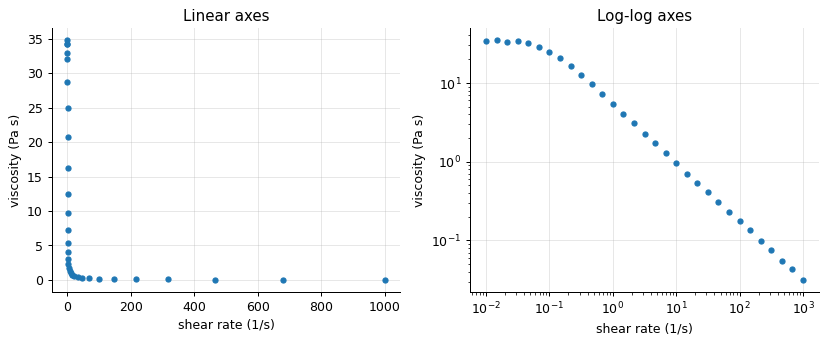

the viscosity falls from 34.8 to 0.0318 Pa s: a factor of 1094


In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(rate, eta, "o", ms=4); a1.set(xlabel="shear rate (1/s)", ylabel="viscosity (Pa s)", title="Linear axes")
a2.loglog(rate, eta, "o", ms=4); a2.set(xlabel="shear rate (1/s)", ylabel="viscosity (Pa s)", title="Log-log axes")
plt.show()
print(f"the viscosity falls from {eta.max():.3g} to {eta.min():.3g} Pa s: a factor of {eta.max()/eta.min():.0f}")

On linear axes everything below about 50 1/s is squeezed into one corner; on log axes the whole curve is
visible: a **Newtonian plateau** at low rates, then **shear thinning**. Flow curves span many decades of
shear rate, so log scales are the norm.

## The local slope: how strongly does it shear-thin?
In the shear-thinning region the curve is nearly straight on log axes, $\eta \propto \dot\gamma^{\,n-1}$. The local
slope $d\ln\eta / d\ln\dot\gamma$ shows where that holds:

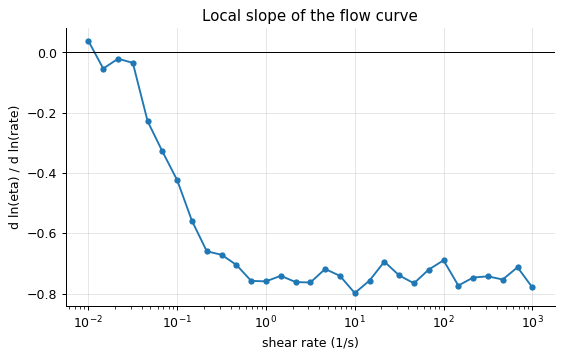

mean slope above 10 1/s: -0.740  ->  power-law index n = 0.260


In [5]:
slope = np.gradient(np.log(eta), np.log(rate))
plt.semilogx(rate, slope, "o-", ms=4)
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("shear rate (1/s)"); plt.ylabel("d ln(eta) / d ln(rate)"); plt.title("Local slope of the flow curve")
plt.show()
high = rate > 10
print(f"mean slope above 10 1/s: {slope[high].mean():.3f}  ->  power-law index n = {1 + slope[high].mean():.3f}")

The slope is near 0 on the plateau and settles to a nearly constant negative value at high rates - the
power-law region. Local slopes of noisy data scatter; averaging over a region steadies them.

## A first fit
A power law $\tau = K\dot\gamma^n$ is a straight line in log-log coordinates, so it can be fitted by linear regression of
$\ln\tau$ on $\ln\dot\gamma$ - which is exactly what `fitting.fit_flow_curve` does for this model:

In [6]:
b, a = np.polyfit(np.log(rate[high]), np.log(tau[high]), 1)
print(f"straight line in log-log coordinates: n = {b:.4f}, K = {np.exp(a):.4f} Pa s^n")
fit = fitting.fit_flow_curve(rate[high], tau[high], "power_law")
print(fit)

straight line in log-log coordinates: n = 0.2634, K = 5.1900 Pa s^n
power_law fit to 12 points: relative scatter 1.81 %, AIC -94.50
parameter    value  std. error  95% low  95% high
-------------------------------------------------
        K     5.19     0.10174   4.9633    5.4167
        n  0.26344    0.003939  0.25466   0.27221


Same numbers - and the library adds the uncertainty of each parameter. Notebook 03 fits models that cover
the whole curve.

## Interpolating on the right scale
What is the viscosity at 50 1/s, between two measured points? Interpolate where the curve is straight -
on the log scale:

In [7]:
target = 50.0
linear = np.interp(target, rate, eta)
logscale = np.exp(np.interp(np.log(target), np.log(rate), np.log(eta)))
print(f"linear interpolation {linear:.4f} Pa s, log-log interpolation {logscale:.4f} Pa s")

linear interpolation 0.2933 Pa s, log-log interpolation 0.2895 Pa s


## Inside the algorithm: the local slope on an uneven grid
`np.gradient` estimates derivatives with second-order differences that allow unequal spacing - here in
$\ln\dot\gamma$. For interior points it weights the two neighbouring slopes by the opposite spacing:

In [8]:
x, y = np.log(rate), np.log(eta)
h1, h2 = x[1:-1] - x[:-2], x[2:] - x[1:-1]
interior = (h1**2 * y[2:] + (h2**2 - h1**2) * y[1:-1] - h2**2 * y[:-2]) / (h1 * h2 * (h1 + h2))
print("max difference from np.gradient:", np.max(np.abs(interior - np.gradient(y, x)[1:-1])))

max difference from np.gradient: 1.2073675392798577e-15


The two differ: linear interpolation draws a straight line on linear axes, which for a power-law curve
lies above the true curve between the points. The difference grows with the spacing of the data.

## Exercises
1. The rheometer's minimum reliable torque is 1 µN·m. What is the lowest shear stress this cone (R = 25 mm)
   can measure? Draw the corresponding "low-torque limit" line $\eta_{min} = \tau_{min}/\dot\gamma$ on the viscosity plot.
   Are all the data safely above it?
2. Read the file again with `np.loadtxt` instead of pandas (hint: `delimiter`, `comments`, `skiprows`).
   When is each tool more convenient?
3. **Implement it yourself:** write `loglog_interp(x0, x, y)` that interpolates linearly in log-log coordinates, and check it against the notebook's result at 50 1/s.